In [2]:
import os
import sys

# Go to project root
sys.path.append(os.path.abspath(".."))

In [3]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import pandas as pd
import numpy as np
import time

from sklearn.model_selection import cross_val_score

from src.modeling import get_models
from src.evaluation import regression_metrics

In [4]:
# Load Processed Data
X_train = joblib.load("../models/preprocessing/X_train.pkl")

X_test = joblib.load("../models/preprocessing/X_test.pkl")

y_train = joblib.load("../models/preprocessing/y_train.pkl")

y_test = joblib.load("../models/preprocessing/y_test.pkl")

In [5]:
# Load Model
models = get_models()
len(models)

9

In [7]:
# Train Every Model
results = []
trained_models = {}
for name, model in models.items():
    print(f"Training {name}")
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    prediction = model.predict(X_test)
    metrics = regression_metrics(y_test, prediction)
    # -----------------------
    # 5-Fold Cross Validation
    # -----------------------
    cv = cross_val_score(model,X_train,y_train,cv=5,scoring="r2")
    trained_models[name] = model
    results.append({
        "Model": name,
        "Training Time": train_time,
        "MAE": metrics["MAE"],
        "MSE": metrics["MSE"],
        "RMSE": metrics["RMSE"],
        "R2 Score": metrics["R2"],
        "CV Mean": cv.mean(),
        "CV Std": cv.std()
    })

Training Linear Regression
Training Ridge Regression
Training Lasso Regression
Training Decision Tree
Training Random Forest
Training Gradient Boosting
Training Support Vector Regressor
Training Extra Trees
Training AdaBoost


In [8]:
# Results Table.
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("R2 Score",ascending=False)
results_df

,Model,Training Time,MAE,MSE,RMSE,R2 Score,CV Mean,CV Std
1,Ridge Regression,0.032212,6135.348427,7.515244e+07,8669.050646,0.822412,0.828434,0.011897
2,Lasso Regression,19.069928,6048.925049,7.867300e+07,8869.779919,0.814093,0.816972,0.016049
0,Linear Regression,0.519583,6608.946057,8.805614e+07,9383.823276,0.791920,0.807810,0.014528
7,Extra Trees,50.813708,7531.731701,1.183167e+08,10877.346215,0.720413,0.743668,0.025947
4,Random Forest,41.768665,8330.782112,1.404812e+08,11852.475738,0.668038,0.709856,0.027905
5,Gradient Boosting,1.488254,9123.181340,1.493943e+08,12222.694450,0.646976,0.699066,0.025280
3,Decision Tree,0.528865,10275.802469,2.241616e+08,14972.028331,0.470298,0.510732,0.035382
8,AdaBoost,1.577000,13633.089705,2.586939e+08,16083.965540,0.388697,0.449134,0.065113
6,Support Vector Regressor,1.125507,15830.685030,4.390175e+08,20952.743493,-0.037414,-0.030899,0.011050


In [9]:
# Save Results
results_df.to_csv(
    "../outputs/tables/model_comparison.csv",
    index=False
)

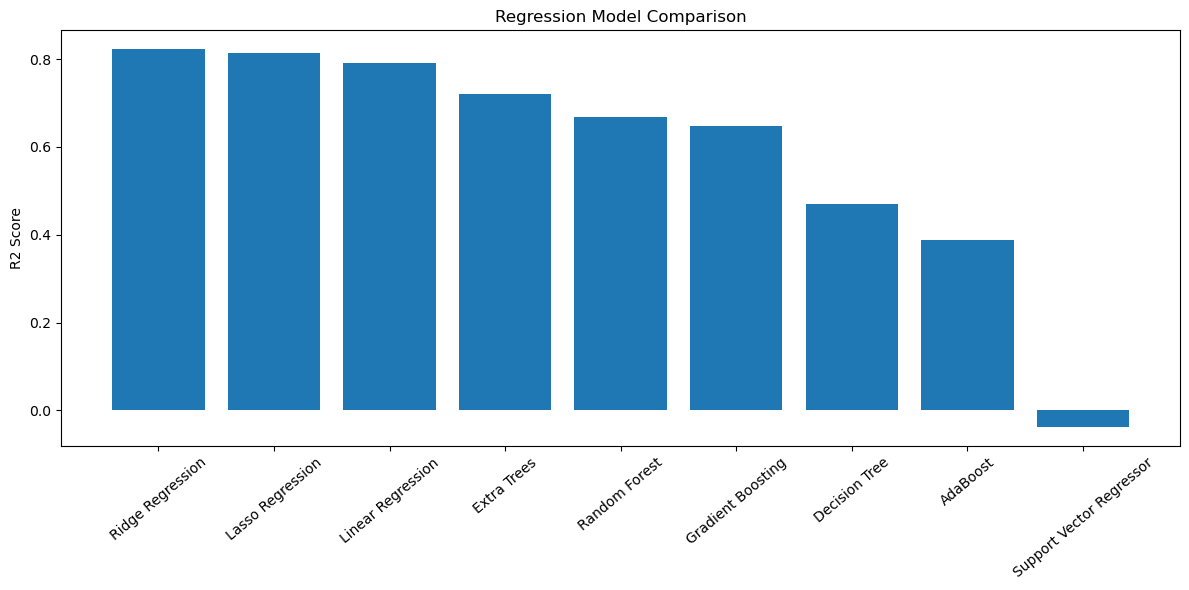

In [10]:
# Model Ranking Plot
from src.visualization import plot_model_ranking
plot_model_ranking(results_df)

In [12]:
import os
os.makedirs("../models/trained_models", exist_ok=True)
for name, model in trained_models.items():
    filename = name.lower().replace(" ", "_") + ".pkl"
    joblib.dump(model,f"../models/trained_models/{filename}")

## Model Comparison Summary

Nine regression models were trained and evaluated using:

- MAE
- MSE
- RMSE
- R² Score
- Training Time
- 5-Fold Cross Validation

The best-performing models will be selected for hyperparameter tuning in the next notebook.

    models/
    ├── trained_models/
    │   ├── linear_regression.pkl
    │   ├── ridge_regression.pkl
    │   ├── lasso_regression.pkl
    │   ├── decision_tree.pkl
    │   ├── random_forest.pkl
    │   ├── gradient_boosting.pkl
    │   ├── support_vector_regressor.pkl
    │   ├── extra_trees.pkl
    │   └── adaboost.pkl
    
    outputs/
    ├── tables/
    │   └── model_comparison.csv
    
    outputs/
    ├── figures/
    │   └── model_comparison.png